In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import numpy as np
from scipy.sparse import csr_matrix
import csv
import random
import pickle

## 按照GlOVE的方式embedding

### 读取数据流文件

In [2]:
import pandas as pd

# 加载csv文件
df = pd.read_csv('./archive/dataset_TSMC2014_TKY.csv')

# 查看前5条记录
df


,userId,venueId,venueCategoryId,venueCategory,latitude,longitude,timezoneOffset,utcTimestamp
0,1541,4f0fd5a8e4b03856eeb6c8cb,4bf58dd8d48988d10c951735,Cosmetics Shop,35.705101,139.619590,540,Tue Apr 03 18:17:18 +0000 2012
1,868,4b7b884ff964a5207d662fe3,4bf58dd8d48988d1d1941735,Ramen / Noodle House,35.715581,139.800317,540,Tue Apr 03 18:22:04 +0000 2012
2,114,4c16fdda96040f477cc473a5,4d954b0ea243a5684a65b473,Convenience Store,35.714542,139.480065,540,Tue Apr 03 19:12:07 +0000 2012
3,868,4c178638c2dfc928651ea869,4bf58dd8d48988d118951735,Food & Drink Shop,35.725592,139.776633,540,Tue Apr 03 19:12:13 +0000 2012
4,1458,4f568309e4b071452e447afe,4f2a210c4b9023bd5841ed28,Housing Development,35.656083,139.734046,540,Tue Apr 03 19:18:23 +0000 2012
...,...,...,...,...,...,...,...,...
573698,326,4bab3456f964a5204d993ae3,4bf58dd8d48988d1e9931735,Music Venue,35.656939,139.702518,540,Sat Feb 16 02:34:35 +0000 2013
573699,853,4b559c09f964a520efe827e3,4bf58dd8d48988d129951735,Train Station,35.858740,139.657286,540,Sat Feb 16 02:34:53 +0000 2013
573700,1502,5101e81ee4b020384100b0a5,4bf58dd8d48988d1dc931735,Tea Room,35.701748,139.771216,540,Sat Feb 16 02:34:55 +0000 2013
573701,408,4bbc5648afe1b7134743304b,4bf58dd8d48988d16e941735,Fast Food Restaurant,35.670465,139.768348,540,Sat Feb 16 02:35:17 +0000 2013


### 类别id去重

In [3]:
#假设类别可以全信息获得，因此不采用截取等方式
veneucatdata =df[["venueCategoryId","venueCategory"]].drop_duplicates()
veneucatdata = veneucatdata.reset_index(drop=True)
veneucatdata = veneucatdata.reset_index().rename(columns={"index":"itemId"})
veneucatdata

,itemId,venueCategoryId,venueCategory
0,0,4bf58dd8d48988d10c951735,Cosmetics Shop
1,1,4bf58dd8d48988d1d1941735,Ramen / Noodle House
2,2,4d954b0ea243a5684a65b473,Convenience Store
3,3,4bf58dd8d48988d118951735,Food & Drink Shop
4,4,4f2a210c4b9023bd5841ed28,Housing Development
...,...,...,...
380,380,4bf58dd8d48988d10b941735,Falafel Restaurant
381,381,5032891291d4c4b30a586d68,Home (private)
382,382,4f4531b14b9074f6e4fb0103,Medical Center
383,383,4bf58dd8d48988d18b941735,Stadium


### 送入glove根据类别名求向量

In [4]:
import torchtext
import re
import numpy as np
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize


embedding = torchtext.vocab.GloVe(name='840B', dim=300)
category_embedding = np.zeros(shape=(veneucatdata.shape[0], 300), dtype=np.float32)
for i, text in enumerate(veneucatdata['venueCategory']):
    clean_text = re.sub(r'[^\w\s]','',text)
    tokens = word_tokenize(clean_text)
    print(tokens)
    category_embedding[i, :] = embedding.get_vecs_by_tokens(tokens).numpy().mean(axis=0)
category_df = pd.DataFrame(category_embedding)
category_df

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\89660\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['Cosmetics', 'Shop']
['Ramen', 'Noodle', 'House']
['Convenience', 'Store']
['Food', 'Drink', 'Shop']
['Housing', 'Development']
['Furniture', 'Home', 'Store']
['Train', 'Station']
['Other', 'Great', 'Outdoors']
['Airport']
['Bus', 'Station']
['Bridge']
['Other', 'Great', 'Outdoors']
['Road']
['Subway']
['Park']
['Post', 'Office']
['Light', 'Rail']
['Shrine']
['Train', 'Station']
['Fast', 'Food', 'Restaurant']
['University']
['Government', 'Building']
['Restaurant']
['Food', 'Drink', 'Shop']
['Café']
['Gym', 'Fitness', 'Center']
['Candy', 'Store']
['Mall']
['Home', 'private']
['Other', 'Nightlife']
['Coffee', 'Shop']
['Office']
['Japanese', 'Restaurant']
['Fried', 'Chicken', 'Joint']
['Bar']
['Toy', 'Game', 'Store']
['Building']
['Scenic', 'Lookout']
['Government', 'Building']
['Flower', 'Shop']
['Train', 'Station']
['Food', 'Drink', 'Shop']
['Miscellaneous', 'Shop']
['Video', 'Store']
['College', 'Academic', 'Building']
['College', 'Academic', 'Building']
['Student', 'Center']
['Inter

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
0,0.220689,-0.091725,-0.019492,0.305835,0.233710,-0.159590,0.436110,0.177548,0.258545,0.092072,...,-0.481805,0.124320,0.492335,-0.235348,-0.050835,-0.459835,0.417585,-0.348355,0.175785,0.402375
1,0.039101,-0.217410,0.132684,-0.205887,0.054913,0.398023,-0.434393,-0.605513,0.357650,0.536067,...,-0.064993,0.082487,0.005999,0.421769,-0.504977,-0.104780,-0.014261,0.025823,0.438740,-0.048510
2,0.193340,0.113535,0.058085,0.136865,0.387455,0.012988,0.079910,-0.102608,0.043620,0.349950,...,-0.713735,0.249050,0.022960,-0.086520,0.306311,-0.170440,0.156695,-0.328740,0.037825,0.501575
3,-0.146283,0.175143,0.371269,0.033363,0.106992,0.388840,-0.206496,0.323313,0.169610,0.523560,...,-0.103793,-0.041147,0.422333,-0.199999,-0.164937,-0.170190,0.268273,-0.353173,0.442273,0.243900
4,-0.043200,-0.090738,-0.000328,-0.114926,-0.030765,-0.169500,0.458750,-0.333290,0.515100,1.476250,...,-0.294505,0.394015,0.400140,0.084600,-0.137695,0.356995,-0.496995,-0.317140,-0.211775,0.195974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,0.536855,-0.257181,0.348735,0.137990,0.444494,0.698430,0.135110,-0.074645,0.406355,0.319765,...,0.289458,0.313235,-0.614680,0.028345,-0.143559,-0.239295,0.367800,-0.132775,0.784225,0.098670
381,0.134430,-0.103765,-0.053090,0.034235,0.147555,-0.204045,0.165286,-0.500670,0.334210,2.002435,...,0.018905,-0.055325,0.019353,-0.077329,0.094947,0.094775,-0.043160,-0.453420,0.321250,0.113265
382,-0.065344,-0.154875,0.057800,0.219950,-0.084860,-0.311045,-0.504460,-0.196035,0.241075,2.302150,...,0.532725,0.108802,0.133628,-0.570365,0.289825,-0.123545,-0.156247,0.403780,-0.072915,0.470620
383,1.076100,0.209490,0.082720,0.108410,0.134310,-0.386120,0.342630,0.620140,0.065012,2.032200,...,-0.123810,0.036539,-0.004859,-0.519120,0.376990,-0.088875,-0.476860,0.334880,0.376840,0.030642


### 给列名

In [5]:
category_df.columns = ["i"+str(i) for i in range(300)]
category_df = category_df.reset_index().rename(columns={"index":"itemId"})
category_df

,itemId,i0,i1,i2,i3,i4,i5,i6,i7,i8,...,i290,i291,i292,i293,i294,i295,i296,i297,i298,i299
0,0,0.220689,-0.091725,-0.019492,0.305835,0.233710,-0.159590,0.436110,0.177548,0.258545,...,-0.481805,0.124320,0.492335,-0.235348,-0.050835,-0.459835,0.417585,-0.348355,0.175785,0.402375
1,1,0.039101,-0.217410,0.132684,-0.205887,0.054913,0.398023,-0.434393,-0.605513,0.357650,...,-0.064993,0.082487,0.005999,0.421769,-0.504977,-0.104780,-0.014261,0.025823,0.438740,-0.048510
2,2,0.193340,0.113535,0.058085,0.136865,0.387455,0.012988,0.079910,-0.102608,0.043620,...,-0.713735,0.249050,0.022960,-0.086520,0.306311,-0.170440,0.156695,-0.328740,0.037825,0.501575
3,3,-0.146283,0.175143,0.371269,0.033363,0.106992,0.388840,-0.206496,0.323313,0.169610,...,-0.103793,-0.041147,0.422333,-0.199999,-0.164937,-0.170190,0.268273,-0.353173,0.442273,0.243900
4,4,-0.043200,-0.090738,-0.000328,-0.114926,-0.030765,-0.169500,0.458750,-0.333290,0.515100,...,-0.294505,0.394015,0.400140,0.084600,-0.137695,0.356995,-0.496995,-0.317140,-0.211775,0.195974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,0.536855,-0.257181,0.348735,0.137990,0.444494,0.698430,0.135110,-0.074645,0.406355,...,0.289458,0.313235,-0.614680,0.028345,-0.143559,-0.239295,0.367800,-0.132775,0.784225,0.098670
381,381,0.134430,-0.103765,-0.053090,0.034235,0.147555,-0.204045,0.165286,-0.500670,0.334210,...,0.018905,-0.055325,0.019353,-0.077329,0.094947,0.094775,-0.043160,-0.453420,0.321250,0.113265
382,382,-0.065344,-0.154875,0.057800,0.219950,-0.084860,-0.311045,-0.504460,-0.196035,0.241075,...,0.532725,0.108802,0.133628,-0.570365,0.289825,-0.123545,-0.156247,0.403780,-0.072915,0.470620
383,383,1.076100,0.209490,0.082720,0.108410,0.134310,-0.386120,0.342630,0.620140,0.065012,...,-0.123810,0.036539,-0.004859,-0.519120,0.376990,-0.088875,-0.476860,0.334880,0.376840,0.030642


### 将去重后的类别id 和 embedding拼接

In [6]:

veneue_featuer = pd.merge(veneucatdata,category_df, on='itemId', how='inner' )
veneue_featuer


,itemId,venueCategoryId,venueCategory,i0,i1,i2,i3,i4,i5,i6,...,i290,i291,i292,i293,i294,i295,i296,i297,i298,i299
0,0,4bf58dd8d48988d10c951735,Cosmetics Shop,0.220689,-0.091725,-0.019492,0.305835,0.233710,-0.159590,0.436110,...,-0.481805,0.124320,0.492335,-0.235348,-0.050835,-0.459835,0.417585,-0.348355,0.175785,0.402375
1,1,4bf58dd8d48988d1d1941735,Ramen / Noodle House,0.039101,-0.217410,0.132684,-0.205887,0.054913,0.398023,-0.434393,...,-0.064993,0.082487,0.005999,0.421769,-0.504977,-0.104780,-0.014261,0.025823,0.438740,-0.048510
2,2,4d954b0ea243a5684a65b473,Convenience Store,0.193340,0.113535,0.058085,0.136865,0.387455,0.012988,0.079910,...,-0.713735,0.249050,0.022960,-0.086520,0.306311,-0.170440,0.156695,-0.328740,0.037825,0.501575
3,3,4bf58dd8d48988d118951735,Food & Drink Shop,-0.146283,0.175143,0.371269,0.033363,0.106992,0.388840,-0.206496,...,-0.103793,-0.041147,0.422333,-0.199999,-0.164937,-0.170190,0.268273,-0.353173,0.442273,0.243900
4,4,4f2a210c4b9023bd5841ed28,Housing Development,-0.043200,-0.090738,-0.000328,-0.114926,-0.030765,-0.169500,0.458750,...,-0.294505,0.394015,0.400140,0.084600,-0.137695,0.356995,-0.496995,-0.317140,-0.211775,0.195974
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,4bf58dd8d48988d10b941735,Falafel Restaurant,0.536855,-0.257181,0.348735,0.137990,0.444494,0.698430,0.135110,...,0.289458,0.313235,-0.614680,0.028345,-0.143559,-0.239295,0.367800,-0.132775,0.784225,0.098670
381,381,5032891291d4c4b30a586d68,Home (private),0.134430,-0.103765,-0.053090,0.034235,0.147555,-0.204045,0.165286,...,0.018905,-0.055325,0.019353,-0.077329,0.094947,0.094775,-0.043160,-0.453420,0.321250,0.113265
382,382,4f4531b14b9074f6e4fb0103,Medical Center,-0.065344,-0.154875,0.057800,0.219950,-0.084860,-0.311045,-0.504460,...,0.532725,0.108802,0.133628,-0.570365,0.289825,-0.123545,-0.156247,0.403780,-0.072915,0.470620
383,383,4bf58dd8d48988d18b941735,Stadium,1.076100,0.209490,0.082720,0.108410,0.134310,-0.386120,0.342630,...,-0.123810,0.036539,-0.004859,-0.519120,0.376990,-0.088875,-0.476860,0.334880,0.376840,0.030642


In [7]:
import json
cat_id_map_dict={}
for index, row in veneue_featuer.iterrows():
        key = str(row[1])
        value = int(row[0])
        cat_id_map_dict[key] = value
with open('./TKY/cat_id_map_dict.json', 'w') as f:
     json.dump(cat_id_map_dict,f)
cat_id_map_dict
# 将venue id 映射 为新的 int 型id，创建 events时要用到


{'4bf58dd8d48988d10c951735': 0,
 '4bf58dd8d48988d1d1941735': 1,
 '4d954b0ea243a5684a65b473': 2,
 '4bf58dd8d48988d118951735': 3,
 '4f2a210c4b9023bd5841ed28': 4,
 '4bf58dd8d48988d1f8941735': 5,
 '4bf58dd8d48988d129951735': 6,
 '4bf58dd8d48988d162941735': 7,
 '4bf58dd8d48988d1eb931735': 8,
 '4bf58dd8d48988d1fe931735': 9,
 '4bf58dd8d48988d1df941735': 10,
 '4bf58dd8d48988d15f941735': 11,
 '4bf58dd8d48988d1f9931735': 12,
 '4bf58dd8d48988d1fd931735': 13,
 '4bf58dd8d48988d163941735': 14,
 '4bf58dd8d48988d172941735': 15,
 '4bf58dd8d48988d1fc931735': 16,
 '4eb1d80a4b900d56c88a45ff': 17,
 '4bf58dd8d48988d12a951735': 18,
 '4bf58dd8d48988d16e941735': 19,
 '4bf58dd8d48988d1ae941735': 20,
 '4bf58dd8d48988d12d941735': 21,
 '4bf58dd8d48988d1c4941735': 22,
 '4bf58dd8d48988d1fa941735': 23,
 '4bf58dd8d48988d16d941735': 24,
 '4bf58dd8d48988d105941735': 25,
 '4bf58dd8d48988d117951735': 26,
 '4bf58dd8d48988d1fd941735': 27,
 '4bf58dd8d48988d103941735': 28,
 '4bf58dd8d48988d11a941735': 29,
 '4bf58dd8d48988d1e0

### PCA降维

In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components=30)
item_df_for_pca = category_df[["i"+str(i) for i in range(300)]]
pca.fit(item_df_for_pca)
item_pca = pca.transform(item_df_for_pca)
item_pca

array([[ 0.6579739 , -2.922702  ,  1.0934361 , ..., -0.13175105,
        -0.6846462 , -0.33275077],
       [ 1.4864686 ,  0.02294022, -0.34576064, ...,  0.720173  ,
         0.49163562, -0.75487614],
       [ 0.46025294, -2.1014924 ,  1.1205301 , ..., -0.03722326,
        -0.15446386, -0.27969325],
       ...,
       [-2.569423  ,  0.5350744 , -1.2220839 , ...,  0.23212   ,
        -0.07523801,  0.0586016 ],
       [-1.9353011 ,  2.6928804 ,  1.7959737 , ..., -0.02009711,
        -0.30192697, -0.22014835],
       [ 1.4558157 , -2.2099452 , -0.12277564, ..., -0.17545977,
         0.07233109,  0.11277895]], dtype=float32)

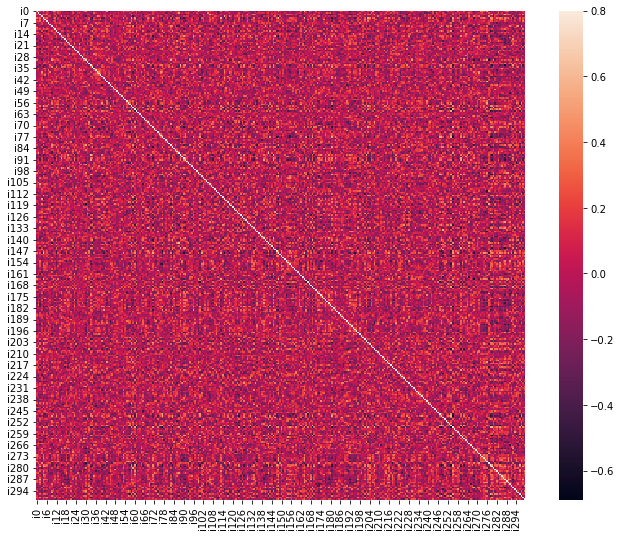

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
corrmat = item_df_for_pca.corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)
plt.show()

<AxesSubplot:>

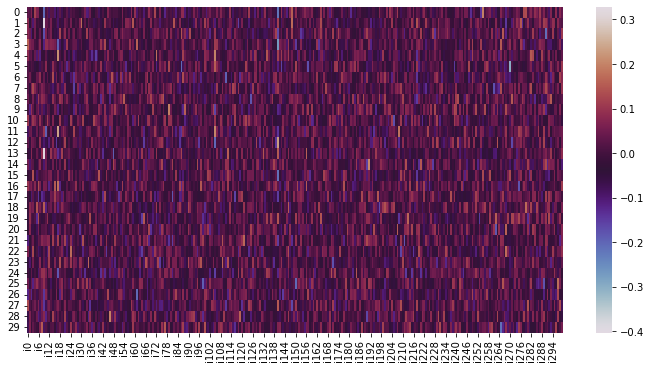

In [10]:
map= pd.DataFrame(pca.components_,columns=item_df_for_pca.columns)
plt.figure(figsize=(12,6))
sns.heatmap(map,cmap='twilight')

In [11]:
# new_item_df = pd.concat([cols["catmapid"], pd.DataFrame(item_pca)], axis=1)
item_pca_df = pd.DataFrame(item_pca)
index_item_pca_df = item_pca_df.reset_index().rename(columns={"index":"itemId"})
index_item_pca_df.columns = ["iid"] + ["i"+str(i) for i in range(30)]
index_item_pca_df
index_item_pca_df


,iid,i0,i1,i2,i3,i4,i5,i6,i7,i8,...,i20,i21,i22,i23,i24,i25,i26,i27,i28,i29
0,0,0.657974,-2.922702,1.093436,-0.321638,0.566710,0.618241,0.577463,0.174613,1.026980,...,0.372413,0.250498,-0.549303,0.601572,0.645974,0.216180,0.203721,-0.131751,-0.684646,-0.332751
1,1,1.486469,0.022940,-0.345761,0.238843,-1.555807,-0.367729,-0.594543,-0.196363,-0.041606,...,0.391831,0.442060,-0.556623,-0.555721,0.128485,0.308736,0.075393,0.720173,0.491636,-0.754876
2,2,0.460253,-2.101492,1.120530,-0.629913,0.076334,-0.134147,-0.052177,0.817060,0.883032,...,-0.362786,-0.125030,0.666046,0.167738,-0.191677,-0.146905,-0.011669,-0.037223,-0.154464,-0.279693
3,3,1.455816,-2.209945,-0.122776,0.022961,-0.345108,-0.137071,0.542443,0.298330,0.300342,...,-0.019057,-0.421162,0.155108,-0.019523,0.568312,0.143099,-0.305424,-0.175460,0.072331,0.112779
4,4,-1.903222,-0.123878,-0.993108,-1.355554,-0.067508,-1.247147,-0.362248,-0.502985,-0.038662,...,1.046179,-0.574999,-0.620744,-0.118753,-0.458025,-0.196459,0.024977,1.253843,-0.161231,0.192673
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380,380,3.373396,0.725187,-0.636794,0.140131,-1.497879,-0.133812,0.216209,0.785519,0.313301,...,-0.207440,-0.069082,-0.126574,-0.048025,-0.100303,-0.177469,0.019176,1.008755,-0.150492,0.861524
381,381,-0.773647,-0.239312,-0.065544,-1.108073,-0.131478,-0.306484,0.233120,-0.661242,-0.299684,...,0.281003,0.030973,-0.685727,-0.110111,0.130980,-0.486787,-0.330197,-0.303068,0.644883,-0.309509
382,382,-2.569423,0.535074,-1.222084,-0.691747,1.139475,0.807539,-0.302311,2.841971,-1.026907,...,-0.451124,0.076153,0.040269,-0.032924,-0.276563,0.253917,0.227430,0.232120,-0.075238,0.058602
383,383,-1.935301,2.692880,1.795974,4.281910,-0.842276,-1.322124,0.727193,1.055992,2.399717,...,-0.193665,0.129745,0.244484,-0.104036,-0.190591,-0.438039,0.101841,-0.020097,-0.301927,-0.220148


In [87]:
index_item_pca_df.to_csv('./TKY/POI_Glove_FeatureVectors.csv', sep=' ', index=False, header=True)
